# Notebook 03 — Train ResNet50 Location Classifier
✔ ResNet training  ✔ Replace last layer  ✔ Pretrained output  ✔ Trained output  ✔ Plot loss

## Cell 1 — Imports and device setup

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## Cell 2 — Load campus dataset

In [4]:
# Diagnostic: Check image files in each class folder
from collections import defaultdict

supported_exts = {'.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp'}
def check_images_in_folder(root):
    issues = defaultdict(list)
    for class_name in os.listdir(root):
        class_path = os.path.join(root, class_name)
        if not os.path.isdir(class_path):
            continue
        files = os.listdir(class_path)
        if not files:
            print(f"[EMPTY] {class_path}")
        found_supported = False
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            if ext in supported_exts:
                found_supported = True
            else:
                issues[class_name].append(f)
        if not found_supported:
            print(f"[NO SUPPORTED IMAGES] {class_path}")
        if issues[class_name]:
            print(f"[UNSUPPORTED FILES] {class_path}: {issues[class_name]}")
    print("Check complete.")

print("\nChecking data/train...")
check_images_in_folder('data/train')
print("\nChecking data/val...")
check_images_in_folder('data/val')


Checking data/train...
[EMPTY] data/train\library_exterior
[NO SUPPORTED IMAGES] data/train\library_exterior
Check complete.

Checking data/val...
[EMPTY] data/val\library_exterior
[NO SUPPORTED IMAGES] data/val\library_exterior
Check complete.


In [6]:
# Image transforms
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

import os
print(f"Current working directory: {os.getcwd()}")
print(f"data/train exists: {os.path.exists('data/train')}")
print(f"data/val exists: {os.path.exists('data/val')}")
if not os.path.exists('data/train') or not os.path.exists('data/val'):
    raise FileNotFoundError("Could not find 'data/train' or 'data/val'. Please check your working directory and folder structure.")

# Load datasets from your folder structure
train_ds = datasets.ImageFolder("data/train", transform=train_tf)
val_ds   = datasets.ImageFolder("data/val",   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

NUM_CLASSES = len(train_ds.classes)
print(f"Number of campus location classes: {NUM_CLASSES}")
print(f"Class names: {train_ds.classes}")
print(f"Training images  : {len(train_ds)}")
print(f"Validation images: {len(val_ds)}")

Current working directory: c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update
data/train exists: True
data/val exists: True
Number of campus location classes: 6
Class names: ['bartels_exterior', 'bergami_exterior', 'dodds_exterior', 'john_and_leona_exterior', 'kaplan_exterior', 'maxy_exterior']
Training images  : 139
Validation images: 49


## Cell 3 — Load ResNet50 and show ORIGINAL last layer
✔ Replace last layer requirement — first we show the original, then we replace it

In [7]:
# Load ResNet50 pretrained on ImageNet
model = models.resnet50(pretrained=True)

print("=" * 55)
print("ORIGINAL ResNet50 last layer (before replacement):")
print("=" * 55)
print(model.fc)
print()
print("→ out_features=1000 means it was classifying 1000 ImageNet classes")
print("→ We need to change this to our campus location classes")

c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\darwa/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


ORIGINAL ResNet50 last layer (before replacement):
Linear(in_features=2048, out_features=1000, bias=True)

→ out_features=1000 means it was classifying 1000 ImageNet classes
→ We need to change this to our campus location classes


## Cell 4 — Replace last layer and freeze all existing layers

In [8]:
# Freeze ALL existing ResNet50 layers
# These pretrained weights stay exactly as they are
for param in model.parameters():
    param.requires_grad = False

# Replace ONLY the final FC layer with our campus classifier
model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)

model = model.to(device)

print("=" * 55)
print("NEW last layer (after replacement):")
print("=" * 55)
print(model.fc)
print()
print(f"→ Final output: {NUM_CLASSES} campus location classes")
print()

# Show trainable parameters
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}  (new head only)")
print(f"Frozen parameters    : {total - trainable:,}  (ResNet50 body)")
print()
print("✓ Only the new last layer will be trained — this is fine-tuning!")

NEW last layer (after replacement):
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=6, bias=True)
)

→ Final output: 6 campus location classes

Total parameters     : 24,560,198
Trainable parameters : 1,052,166  (new head only)
Frozen parameters    : 23,508,032  (ResNet50 body)

✓ Only the new last layer will be trained — this is fine-tuning!


## Cell 5 — Show PRETRAINED output BEFORE training
✔ Show pretrained output requirement — this will be wrong/random, that is expected

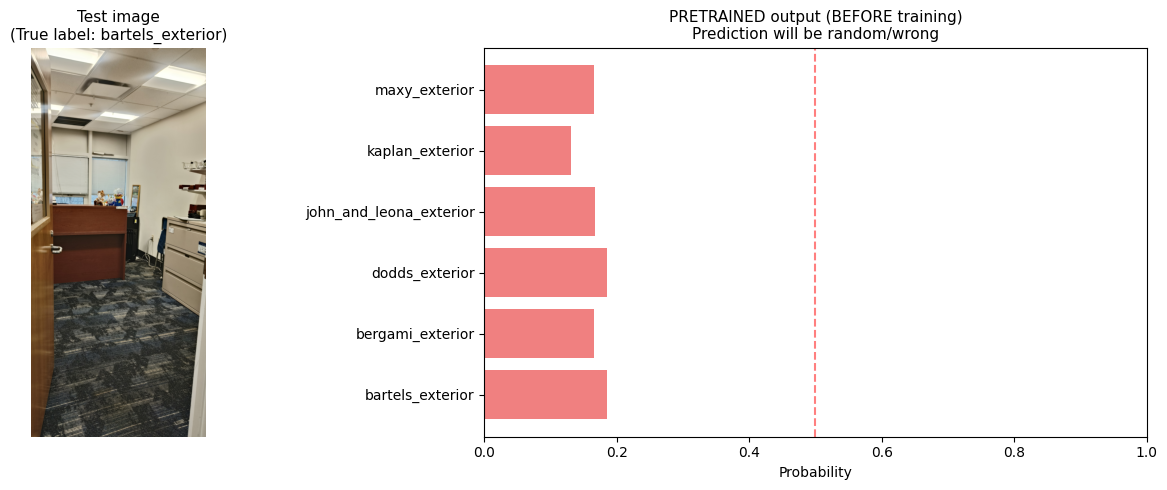

PRETRAINED OUTPUT — BEFORE TRAINING
True label      : bartels_exterior
Predicted class : bartels_exterior
Confidence      : 18.6%

All class probabilities:
  bartels_exterior                    █████ 0.1860
  bergami_exterior                    ████ 0.1650
  dodds_exterior                      █████ 0.1856
  john_and_leona_exterior             █████ 0.1668
  kaplan_exterior                     ███ 0.1303
  maxy_exterior                       ████ 0.1664

→ This prediction is wrong/random — that is EXPECTED before training!
✓ Saved as pretrained_output.png


In [9]:
# Get one validation image to test on
val_classes = os.listdir("data/val")
test_class  = val_classes[0]
test_folder = f"data/val/{test_class}"
test_image  = os.listdir(test_folder)[0]
test_path   = f"{test_folder}/{test_image}"

# Load and display the image
img_pil    = Image.open(test_path).convert("RGB")
img_tensor = val_tf(img_pil).unsqueeze(0).to(device)

# Run through model BEFORE any training
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs  = torch.softmax(output, dim=1)
    conf, idx = probs.max(dim=1)

# Display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(img_pil)
ax1.set_title(f"Test image\n(True label: {test_class})", fontsize=11)
ax1.axis("off")

ax2.barh(train_ds.classes,
         [probs[0][i].item() for i in range(NUM_CLASSES)],
         color="lightcoral")
ax2.set_xlabel("Probability")
ax2.set_title("PRETRAINED output (BEFORE training)\nPrediction will be random/wrong", fontsize=11)
ax2.set_xlim(0, 1)
ax2.axvline(x=0.5, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("pretrained_output.png", dpi=150, bbox_inches="tight")
plt.show()

print("=" * 55)
print("PRETRAINED OUTPUT — BEFORE TRAINING")
print("=" * 55)
print(f"True label      : {test_class}")
print(f"Predicted class : {train_ds.classes[idx.item()]}")
print(f"Confidence      : {conf.item():.1%}")
print()
print("All class probabilities:")
for cls, p in zip(train_ds.classes, probs[0]):
    bar = "█" * int(p.item() * 30)
    print(f"  {cls:35s} {bar} {p.item():.4f}")
print()
print("→ This prediction is wrong/random — that is EXPECTED before training!")
print("✓ Saved as pretrained_output.png")

## Cell 6 — Training loop with CrossEntropy Loss

In [10]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=7, gamma=0.1)

train_losses, val_losses, val_accs = [], [], []
EPOCHS = 20

print("Starting ResNet50 training...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 44)

for epoch in range(EPOCHS):

    # ── TRAIN ────────────────────────────────────────
    model.train()
    running = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_loss = running / len(train_loader)

    # ── VALIDATE ──────────────────────────────────────
    model.eval()
    v_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            v_loss  += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    val_loss = v_loss / len(val_loader)
    val_acc  = correct / total * 100

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step()

    print(f"{epoch+1:>6} | {train_loss:>10.4f} | {val_loss:>8.4f} | {val_acc:>7.1f}%")

# Save model
torch.save({
    "model_state_dict": model.state_dict(),
    "classes"         : train_ds.classes,
    "num_classes"     : NUM_CLASSES
}, "resnet50_campus.pth")
print("\n✓ Training complete! Model saved as resnet50_campus.pth")

Starting ResNet50 training...
 Epoch | Train Loss | Val Loss |  Val Acc
--------------------------------------------
     1 |     1.9193 |   1.5731 |    24.5%
     2 |     1.5177 |   1.5486 |    49.0%
     3 |     1.4107 |   1.3542 |    42.9%
     4 |     1.2108 |   1.3691 |    40.8%
     5 |     1.2511 |   1.2609 |    44.9%
     6 |     1.1061 |   1.1167 |    53.1%
     7 |     1.0944 |   1.0984 |    55.1%
     8 |     0.9957 |   1.0697 |    53.1%
     9 |     1.0532 |   1.0274 |    57.1%
    10 |     1.0021 |   1.0135 |    61.2%
    11 |     1.0433 |   1.0014 |    61.2%
    12 |     0.9979 |   0.9871 |    61.2%
    13 |     0.9632 |   0.9851 |    61.2%
    14 |     0.9178 |   0.9822 |    59.2%
    15 |     1.0171 |   0.9901 |    59.2%
    16 |     0.9426 |   0.9861 |    59.2%
    17 |     1.0115 |   0.9853 |    61.2%
    18 |     0.9581 |   0.9828 |    57.1%
    19 |     0.9720 |   0.9815 |    61.2%
    20 |     0.9361 |   0.9849 |    59.2%

✓ Training complete! Model saved as resnet

## Cell 7 — Plot loss curves
✔ Plot loss requirement

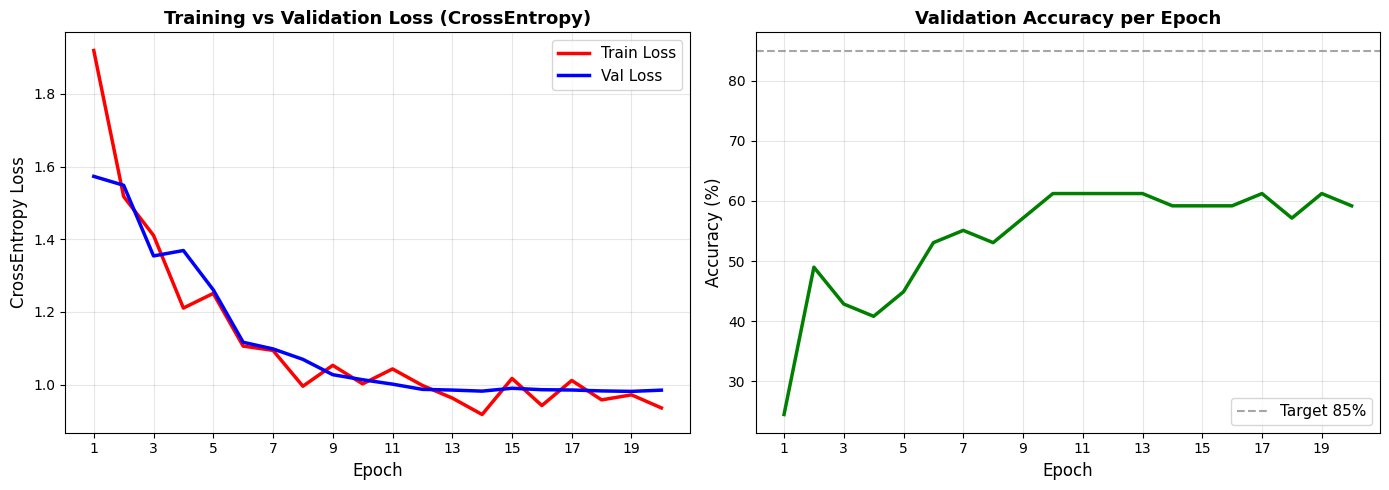

✓ Saved as resnet50_loss_curves.png — include this in your report!


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_losses,
         label="Train Loss", color="red", linewidth=2.5)
ax1.plot(range(1, EPOCHS+1), val_losses,
         label="Val Loss",   color="blue", linewidth=2.5)
ax1.set_title("Training vs Validation Loss (CrossEntropy)",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("CrossEntropy Loss", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_xticks(range(1, EPOCHS+1, 2))

ax2.plot(range(1, EPOCHS+1), val_accs,
         color="green", linewidth=2.5)
ax2.axhline(y=85, color="gray", linestyle="--",
            label="Target 85%", alpha=0.7)
ax2.set_title("Validation Accuracy per Epoch",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_xticks(range(1, EPOCHS+1, 2))

plt.tight_layout()
plt.savefig("resnet50_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved as resnet50_loss_curves.png — include this in your report!")

## Cell 8 — Show TRAINED output AFTER training
✔ Show trained output requirement

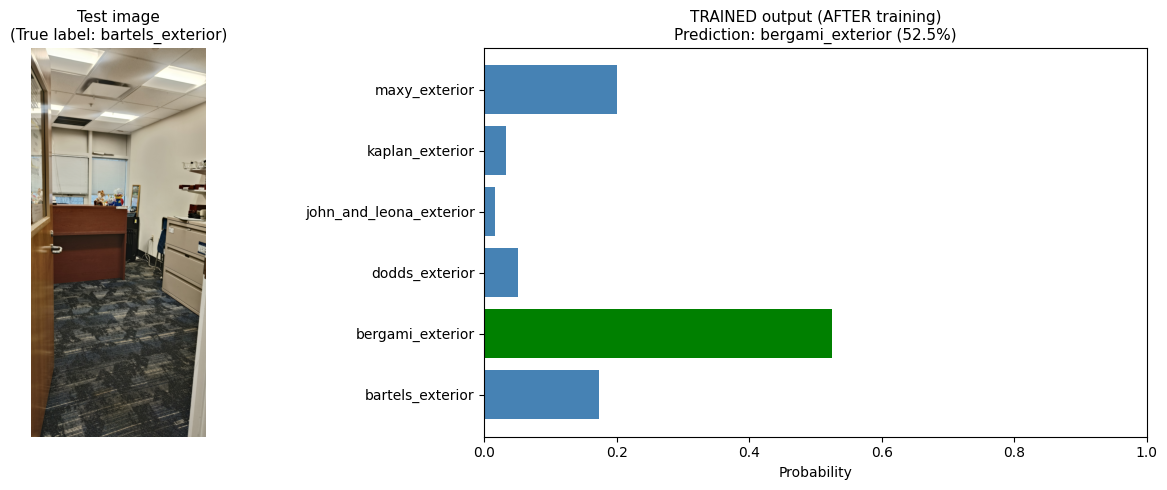

TRAINED OUTPUT — AFTER TRAINING
True label      : bartels_exterior
Predicted class : bergami_exterior
Confidence      : 52.5%

All class probabilities:
  bartels_exterior                    █████ 0.1725
  bergami_exterior                    ███████████████ 0.5254 ← PREDICTED
  dodds_exterior                      █ 0.0513
  john_and_leona_exterior              0.0168
  kaplan_exterior                     █ 0.0333
  maxy_exterior                       ██████ 0.2007

✓ Saved as trained_output.png


In [12]:
# Run the SAME test image through the model AFTER training
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs  = torch.softmax(output, dim=1)
    conf, idx = probs.max(dim=1)

# Display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(img_pil)
ax1.set_title(f"Test image\n(True label: {test_class})", fontsize=11)
ax1.axis("off")

colors = ["green" if cls == train_ds.classes[idx.item()]
          else "steelblue" for cls in train_ds.classes]
ax2.barh(train_ds.classes,
         [probs[0][i].item() for i in range(NUM_CLASSES)],
         color=colors)
ax2.set_xlabel("Probability")
ax2.set_title(f"TRAINED output (AFTER training)\nPrediction: {train_ds.classes[idx.item()]} ({conf.item():.1%})",
              fontsize=11)
ax2.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("trained_output.png", dpi=150, bbox_inches="tight")
plt.show()

print("=" * 55)
print("TRAINED OUTPUT — AFTER TRAINING")
print("=" * 55)
print(f"True label      : {test_class}")
print(f"Predicted class : {train_ds.classes[idx.item()]}")
print(f"Confidence      : {conf.item():.1%}")
print()
print("All class probabilities:")
for cls, p in zip(train_ds.classes, probs[0]):
    bar = "█" * int(p.item() * 30)
    mark = " ← PREDICTED" if cls == train_ds.classes[idx.item()] else ""
    print(f"  {cls:35s} {bar} {p.item():.4f}{mark}")
print()
print("✓ Saved as trained_output.png")